# Супердупер продвинутый анализ

мы найдем навыки, которые связаны с большой зарплатой 

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
totaly_df = pd.read_csv('totaly_final_df.csv')

# оставляем нужное
df = totaly_df[totaly_df['salary'].notna()]
df.reset_index(drop=True, inplace=True)
df.drop(columns=['country', 'company_staff_count', 'education'], inplace=True)

df

/var/folders/v8/lqntntc15fgctlxw4wdhwhx80000gn/T/ipykernel_46088/1881270892.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['country', 'company_staff_count', 'education'], inplace=True)


,profession,company,vac_description,experience,region,salary
0,Разработчик,Детский хоспис Дом с маяком,"['JSON', 'API', 'знание', 'REST', 'Git', 'REST...",1,Московская область,95000.0
1,Unity-разработчик,ООО Нектар,"['C', 'Алгоритмы и структуры данных', 'классич...",6,Московская область,150000.0
2,Ведущий разработчик,БИТ,"['T-SQL', 'JavaScript', 'MS SQL', 'pl', 'MS SQ...",1,Московская область,200000.0
3,RTL-разработчик,ООО Трамплин Электроникс,"['level', 'RTL', 'Verilog', 'знание']",3,Московская область,200000.0
4,Повар-разработчик,ООО ПРОМЫШЛЕННАЯ КУЛИНАРИЯ,['понимание'],3,Московская область,120000.0
...,...,...,...,...,...,...
3285,Продавец в зону готовой еды,"Магнит, Розничная сеть","['продажи', 'ДО', 'акции']",0,Калужская область,39500.0
3286,Мерчандайзер магазина (метро Речной Вокзал),FIX PRICE,"['ДО', 'Обучение']",0,Московская область,71500.0
3287,"Продавец-кассир в магазин, продавец консультан...","""БЭСТ ПРАЙС"" / Fix Price","['ДО', 'консультант', 'Обучение']",0,Московская область,71500.0
3288,"Старший продавец-кассир, администратор в магазин","""БЭСТ ПРАЙС"" / Fix Price","['Поддержка', 'ДО', 'Обучение', 'телемедицина'...",1,Московская область,79000.0


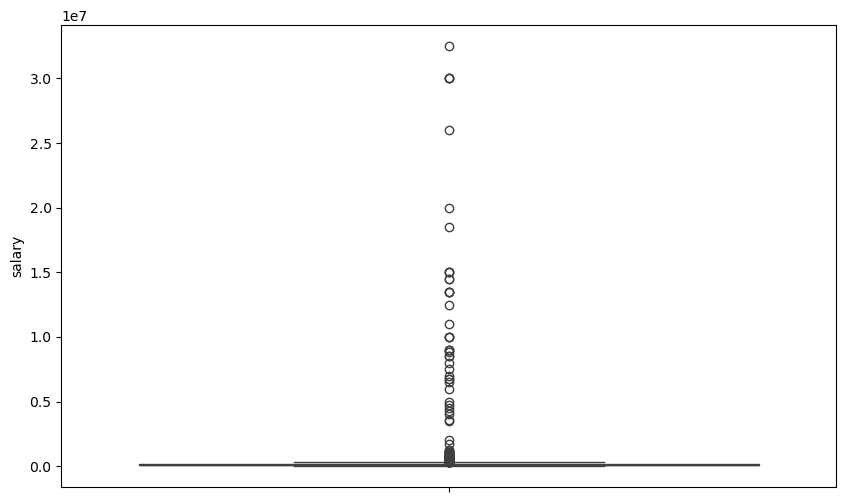

In [191]:
# поглядим на уровень зп

plt.figure(figsize=(10, 6))
sns.boxplot(df['salary'])
plt.show()

# ну дела

In [192]:
# поработаем с выбросами

df = df[df['salary'] != 0]
df.reset_index(drop=True, inplace=True)

big_salary_mask = df['salary'] > df['salary'].quantile(0.98)
df = df[~big_salary_mask]

smol_salary_mask = df['salary'] < df['salary'].quantile(0.02)
df = df[~smol_salary_mask]

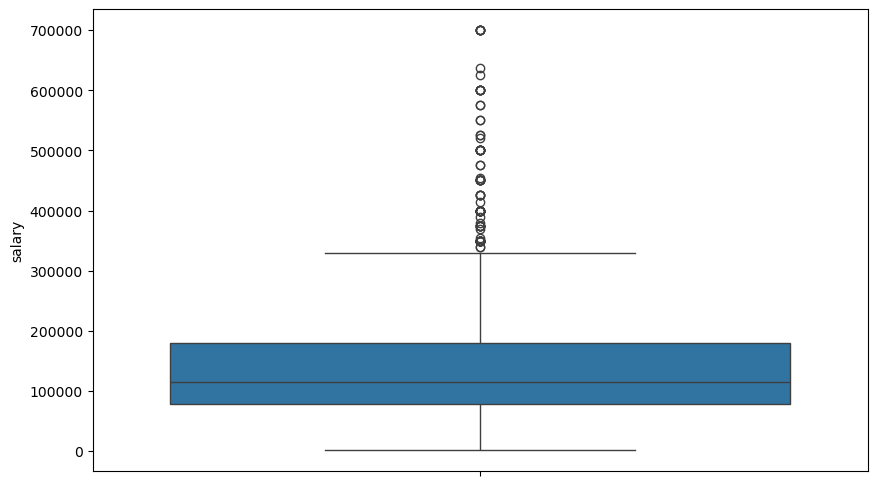

In [193]:
plt.figure(figsize=(10, 6))
sns.boxplot(df['salary'])
plt.show()

# класс

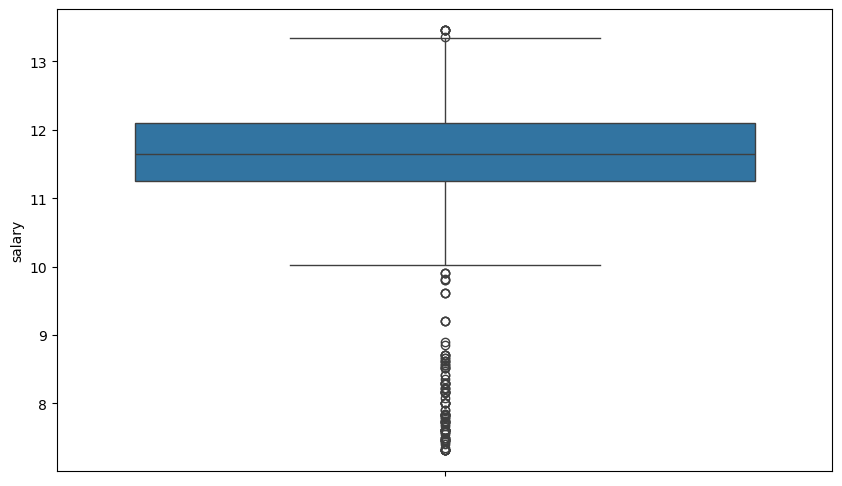

In [194]:
# логарифмирование

df['salary'] = np.log1p(df['salary'])

plt.figure(figsize=(10, 6))
sns.boxplot(df['salary'])
plt.show()

# лан пойдет

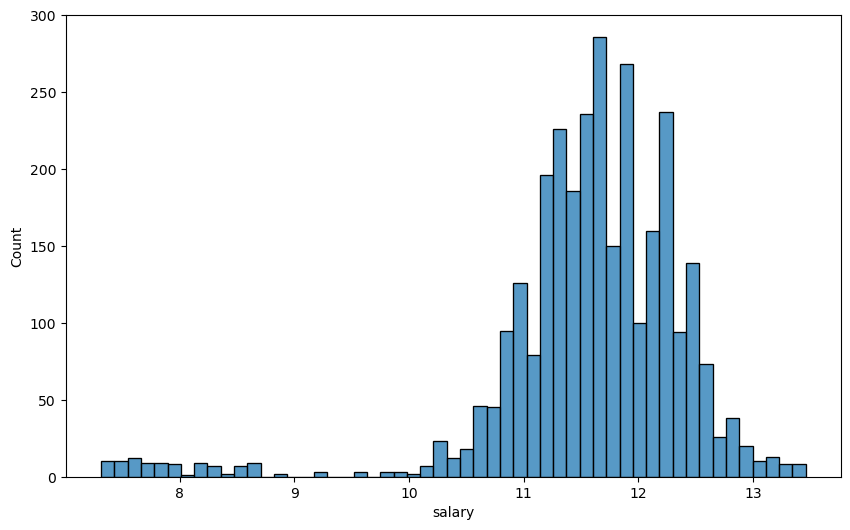

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'])
plt.show()


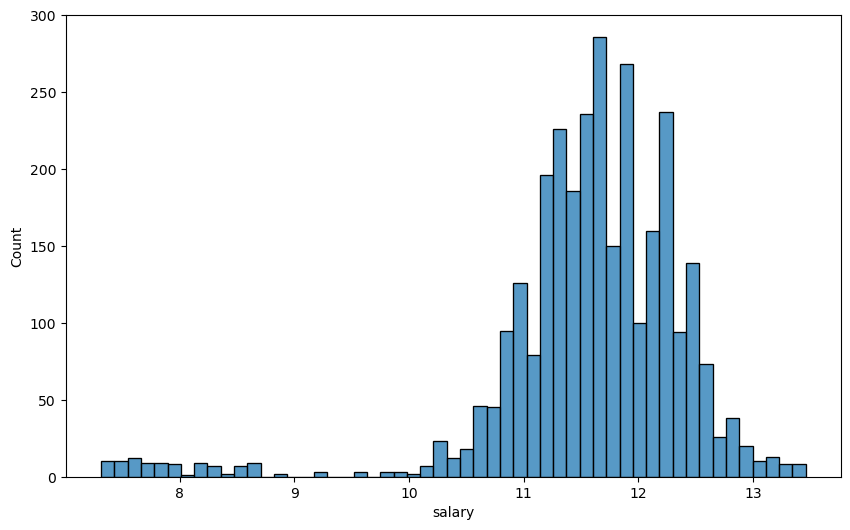

In [196]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'])
plt.show()

# ну пойдет

In [197]:
from ast import literal_eval

df.dropna(subset=['vac_description'], inplace=True)

# преобразуем в список из строки
df["vac_description"] = df["vac_description"].apply(literal_eval)
df

,profession,company,vac_description,experience,region,salary
0,Разработчик,Детский хоспис Дом с маяком,"[JSON, API, знание, REST, Git, REST API, Pytho...",1,Московская область,11.461643
1,Unity-разработчик,ООО Нектар,"[C, Алгоритмы и структуры данных, классические...",6,Московская область,11.918397
2,Ведущий разработчик,БИТ,"[T-SQL, JavaScript, MS SQL, pl, MS SQL Server,...",1,Московская область,12.206078
3,RTL-разработчик,ООО Трамплин Электроникс,"[level, RTL, Verilog, знание]",3,Московская область,12.206078
4,Повар-разработчик,ООО ПРОМЫШЛЕННАЯ КУЛИНАРИЯ,[понимание],3,Московская область,11.695255
...,...,...,...,...,...,...
3149,Продавец в зону готовой еды,"Магнит, Розничная сеть","[продажи, ДО, акции]",0,Калужская область,10.584081
3150,Мерчандайзер магазина (метро Речной Вокзал),FIX PRICE,"[ДО, Обучение]",0,Московская область,11.177467
3151,"Продавец-кассир в магазин, продавец консультан...","""БЭСТ ПРАЙС"" / Fix Price","[ДО, консультант, Обучение]",0,Московская область,11.177467
3152,"Старший продавец-кассир, администратор в магазин","""БЭСТ ПРАЙС"" / Fix Price","[Поддержка, ДО, Обучение, телемедицина, консул...",1,Московская область,11.277216


In [198]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

In [199]:
X_skills = pd.DataFrame(mlb.fit_transform(df['vac_description']), index=df.index, columns=mlb.classes_)
X_skills

,*nix,.NET,.NET Core,.NET Framework,.net 8,1С,1С 7.7,1С 8,1С 8.3,1С ЗУП 3.1,...,финансы,фотография,функциональное тестирование,функциональные,цветокоррекция,эквайринг,экономика,юзабилити,язык программирования,языки
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3151,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3152,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [205]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [206]:
X = X_skills
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(
    X_skills, df['salary'], test_size=0.2, random_state=555
)

model = RidgeCV()

model.fit(X, y)

y_pred = model.predict(X_test)

r2_score(y_test, y_pred)

0.2886537149484726

Это досаточно много для такой индустрии, значит считаем что коэффициенты модели валидно отображают реальный расклад

In [207]:
# смотрим на коэффициенты

coef = pd.Series(model.coef_, index=X.columns)
premium = (np.exp(coef) - 1) * 100
print(premium.sort_values(ascending=False).head(30))

Go                        50.914488
подготовка предложений    40.126927
Symfony                   40.074158
AutoCAD                   39.106409
GOlang                    33.989234
Fullstack                 33.838889
Spring                    29.508489
Kotlin                    28.487150
1С                        28.179375
low-code                  26.508436
ERP                       26.280508
auto                      26.236636
b2b                       24.983125
apps                      24.933463
Power Apps                24.933463
Программирование          24.840747
опыт проектирования       24.478507
архитектура               23.819982
Swagger                   23.337229
React                     22.810087
project                   22.439832
components                20.148070
ETL                       20.090643
АСУ ТП                    19.750122
SDK                       19.731334
PPC                       19.143693
Swift                     19.047103
Digital                   18